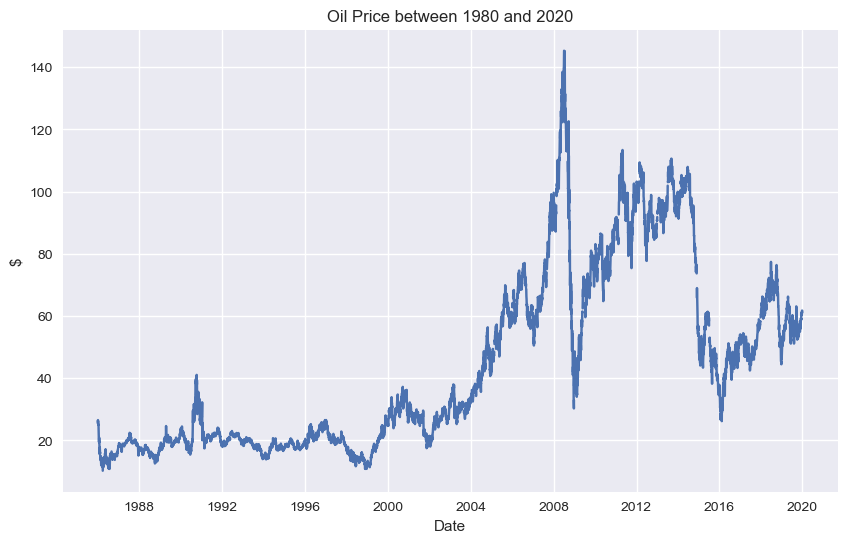

In [2]:

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import fredapi 
from fredapi import Fred

plt.style.use('seaborn')

Fred = Fred(api_key='1aaa8b6c59bddd5717ffa60e65d5f6b3')

# Get the oil price data
oil_price = Fred.get_series('DCOILWTICO')
                            
oil_price = oil_price['1980-01-01':'2020-01-01']

plt.figure(figsize=(10,6))
plt.plot(oil_price)
plt.title('Oil Price between 1980 and 2020')
plt.xlabel('Date')
plt.ylabel('$')
plt.show()

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import datetime
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller 
from statsmodels.tsa.seasonal import seasonal_decompose

In [4]:
ticker = '^GSPC'
start = datetime.datetime(2015, 1, 1)
end = datetime.datetime(2024, 1, 1)
SP_prices = yf.download(ticker, start=start, end=end, interval='1mo')\
            .Close

[*********************100%***********************]  1 of 1 completed


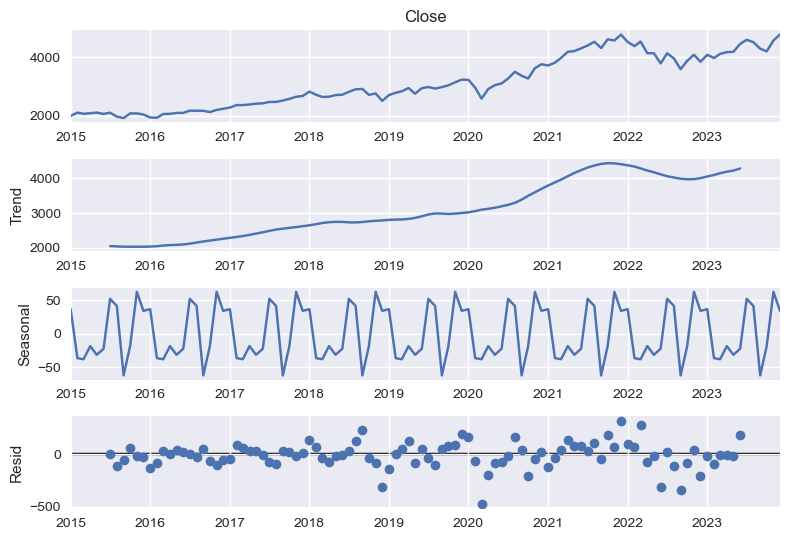

In [5]:
seasonal_decompose(SP_prices, period=12).plot()
plt.show()

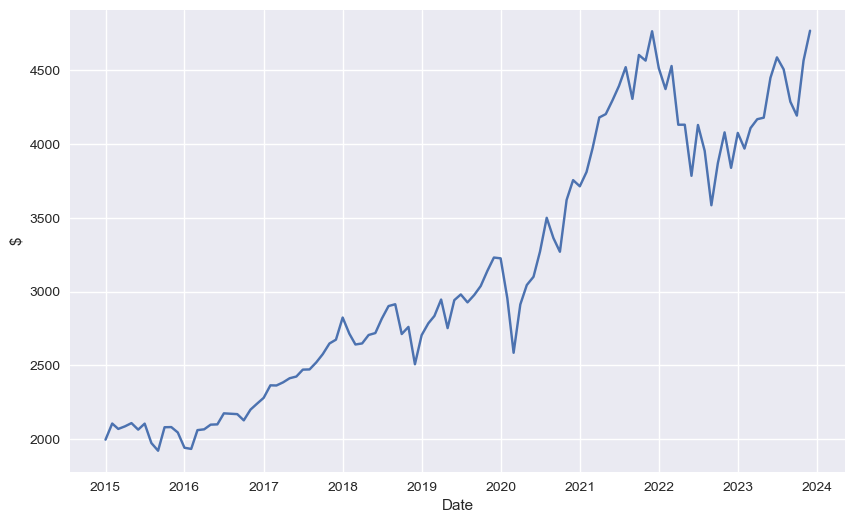

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(SP_prices)
plt.ylabel('$')
plt.xlabel('Date')
plt.show()

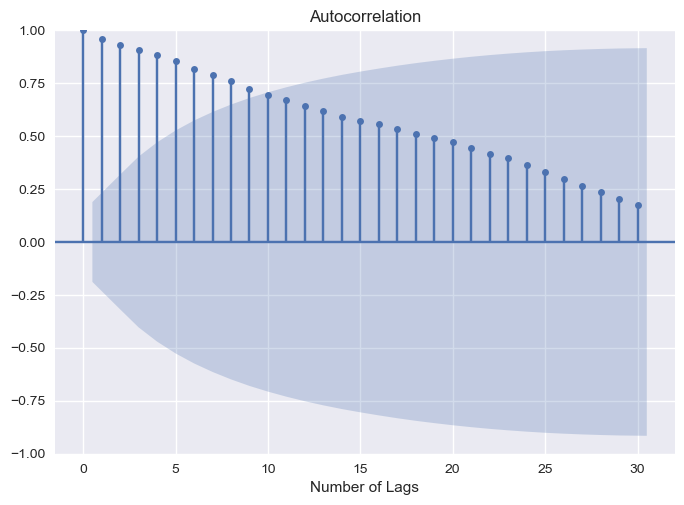

In [7]:
sm.graphics.tsa.plot_acf(SP_prices, lags=30)
plt.xlabel('Number of Lags')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

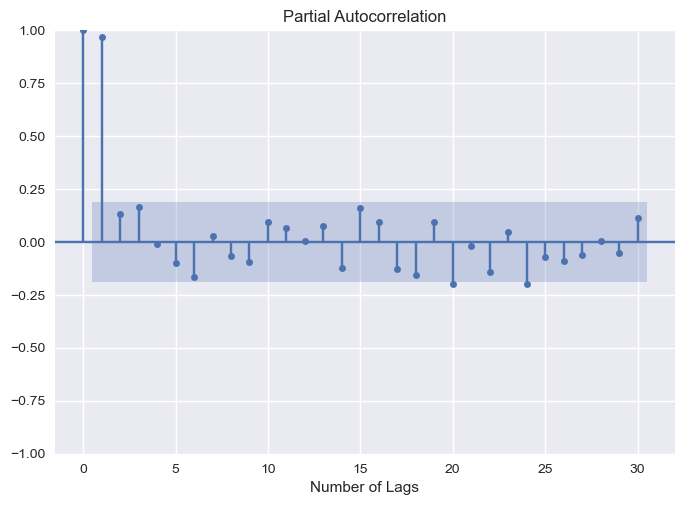

In [8]:
sm.graphics.tsa.plot_pacf(SP_prices, lags=30)
plt.xlabel('Number of Lags')
plt.show

In [9]:
from fredapi import Fred
import statsmodels.api as sm

fred = Fred(api_key = '1aaa8b6c59bddd5717ffa60e65d5f6b3')

energy = fred.get_series('CAPUTLG2211A2S')

energy = energy['2010-01-01' : '2020-12-31']

In [10]:
energy.head(12)

2010-01-01    83.6433
2010-02-01    84.8414
2010-03-01    81.9267
2010-04-01    79.3583
2010-05-01    82.6349
2010-06-01    84.2155
2010-07-01    83.4218
2010-08-01    83.5761
2010-09-01    83.5229
2010-10-01    80.6774
2010-11-01    81.5641
2010-12-01    85.7813
dtype: float64

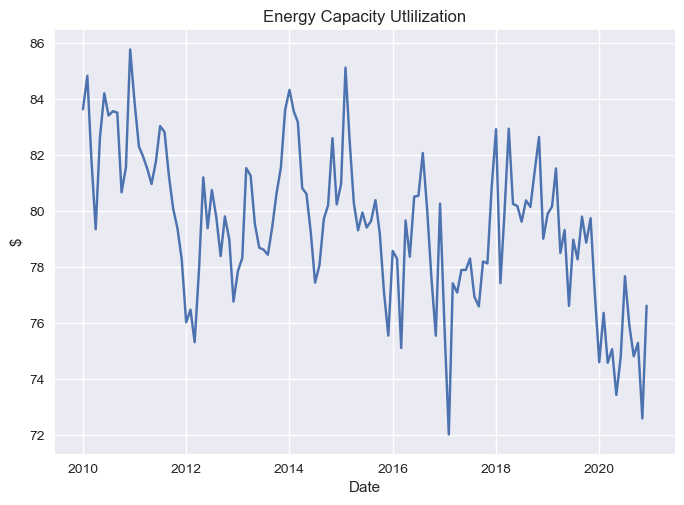

In [11]:
plt.plot(energy)
plt.title('Energy Capacity Utlilization')
plt.ylabel('$')
plt.xlabel('Date')
plt.show()

In [12]:
stat_test = adfuller(SP_prices)[0:2]
print("The test statisitc and p-value of ADF test are {}".format(stat_test))

The test statisitc and p-value of ADF test are (-0.15962105988183314, 0.943166637799894)


In [13]:
diff_SP_price = SP_prices.diff()


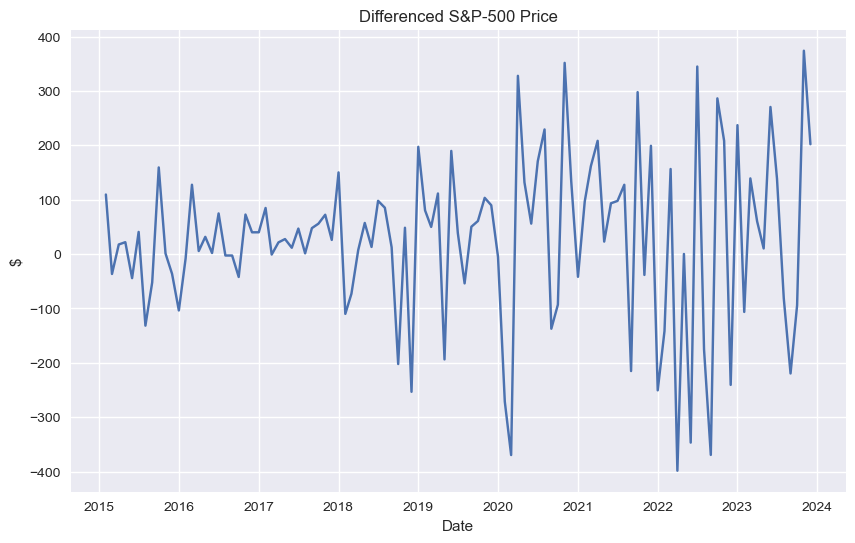

In [14]:
plt.figure(figsize=(10,6))
plt.plot(diff_SP_price)
plt.title('Differenced S&P-500 Price')
plt.ylabel('$')
plt.xlabel('Date')
plt.show()

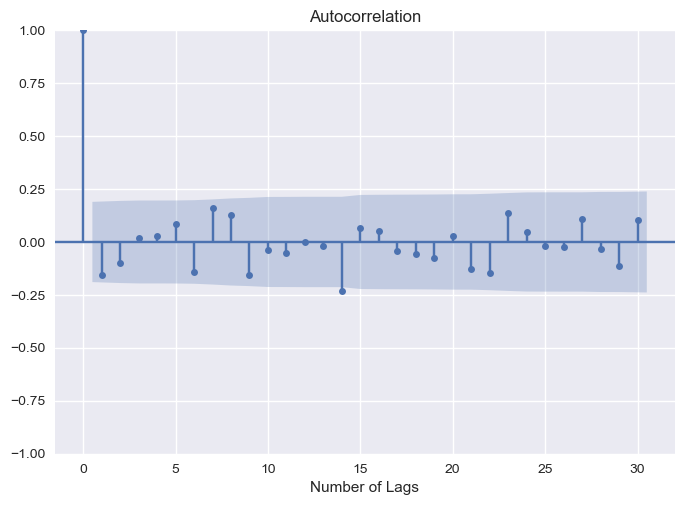

In [15]:
sm.graphics.tsa.plot_acf(diff_SP_price.dropna(), lags=30)
plt.xlabel('Number of Lags')
plt.show()

In [16]:
stat_test2 = adfuller(diff_SP_price.dropna())[0:2]
print('The text statistic and p-value of ADF test after differencing are {}'\
        .format(stat_test2))


The text statistic and p-value of ADF test after differencing are (-11.890753731299425, 5.876499868364346e-22)


In [17]:
seasonal_index = energy.resample('Q').mean()


In [18]:
dates = energy.index.year.unique()
deseasonalized = []

for i in dates:
    for j in range(1, 13):
        deseasonalized.append((energy[str(i)][energy[str(i)]\
                                            .index.month==j]))
        concat_deseasonalized = np.concatenate(deseasonalized)
        

In [19]:
deseason_energy = []

for i,s in zip(range(0, len(energy), 3), range(len(seasonal_index))):
    deseason_energy.append(concat_deseasonalized[i:i+3] /
                          seasonal_index.iloc[s])
    
concat_deseason_energy = np.concatenate(deseason_energy)
deseason_energy = pd.DataFrame(concat_deseason_energy,
                                  index=energy.index)
deseason_energy.columns = ['Deseasonalized Energy']
deseason_energy.head()

,Deseasonalized Energy
2010-01-01,1.002071
2010-02-01,1.016424
2010-03-01,0.981505
2010-04-01,0.966964
2010-05-01,1.006888


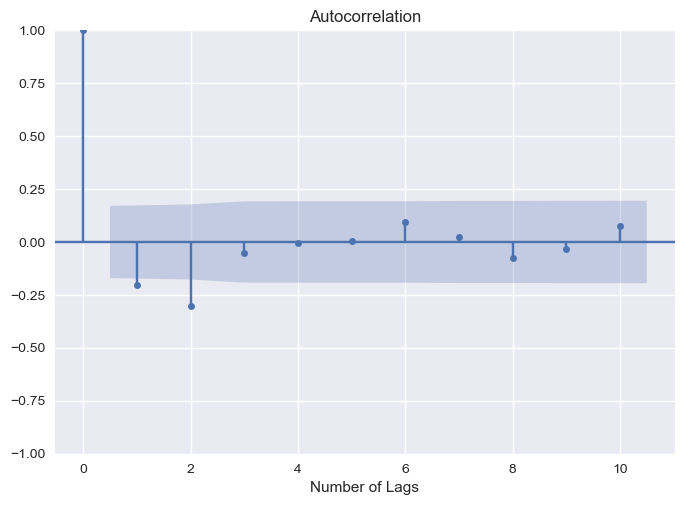

In [20]:
sm.graphics.tsa.plot_acf(deseason_energy, lags=10)
plt.xlabel('Number of Lags')
plt.show()

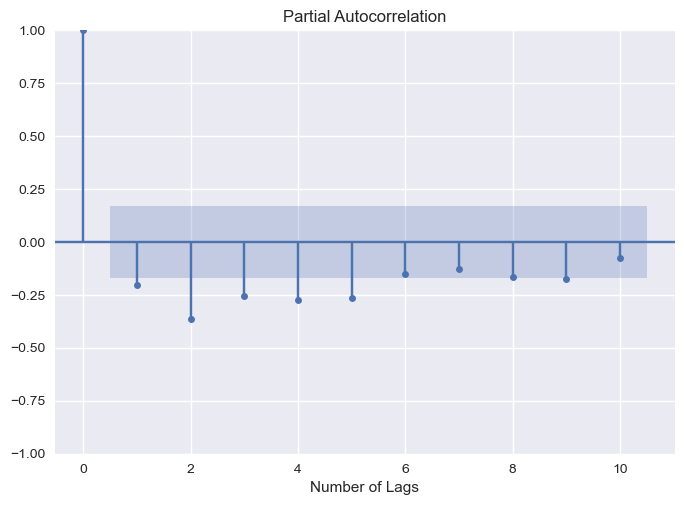

In [21]:
sm.graphics.tsa.plot_pacf(deseason_energy, lags=10)
plt.xlabel('Number of Lags')
plt.show()

In [22]:
mu = 0
std = 1


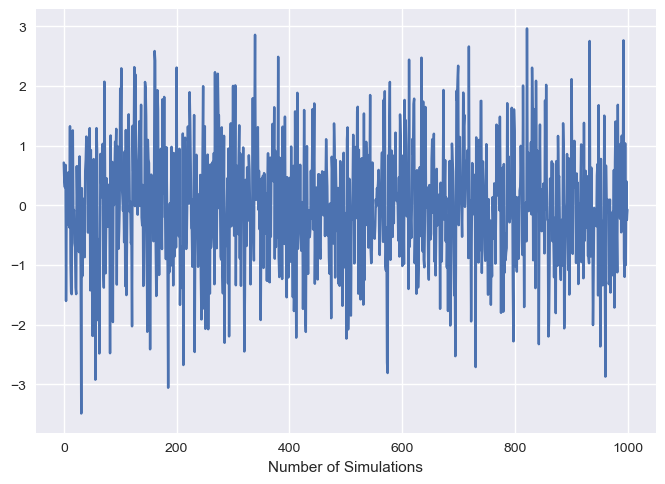

In [23]:
WN = np.random.normal(mu, std, 1000)

plt.plot(WN)
plt.xlabel('Number of Simulations')
plt.show()

In [24]:
ticker = ['AAPL', 'MSFT']
start = datetime.datetime(2019, 1, 1)
end = datetime.datetime(2021, 1, 1)

stock_prices = yf.download(ticker, start, end, interval='1d')\
               .Close

[*********************100%***********************]  2 of 2 completed


In [25]:
stock_prices = stock_prices.dropna()

for i in ticker:
    stat_test = adfuller(stock_prices[i])[0:2]
    print('The ADF test statistic and p-value of {} are {}'\
         .format(i,stat_test))

The ADF test statistic and p-value of AAPL are (0.30197458557904655, 0.9774348980254369)
The ADF test statistic and p-value of MSFT are (-0.7838047612900143, 0.8238330701563916)


In [26]:
diff_stock_prices = stock_prices.diff().dropna()

split = int(len(diff_stock_prices['AAPL'].values) * 0.95)
diff_train_aapl = diff_stock_prices['AAPL'].iloc[:split]
diff_test_aapl = diff_stock_prices['AAPL'].iloc[split:]
diff_train_msft = diff_stock_prices['MSFT'].iloc[:split]
diff_test_msft = diff_stock_prices['MSFT'].iloc[split:]

In [27]:
diff_train_aapl.to_csv('diff_train_aapl.csv')
diff_test_aapl.to_csv('diff_test_aapl.csv')
diff_train_msft.to_csv('diff_train_msft.csv')
diff_test_msft.to_csv('diff_test_msft.csv')

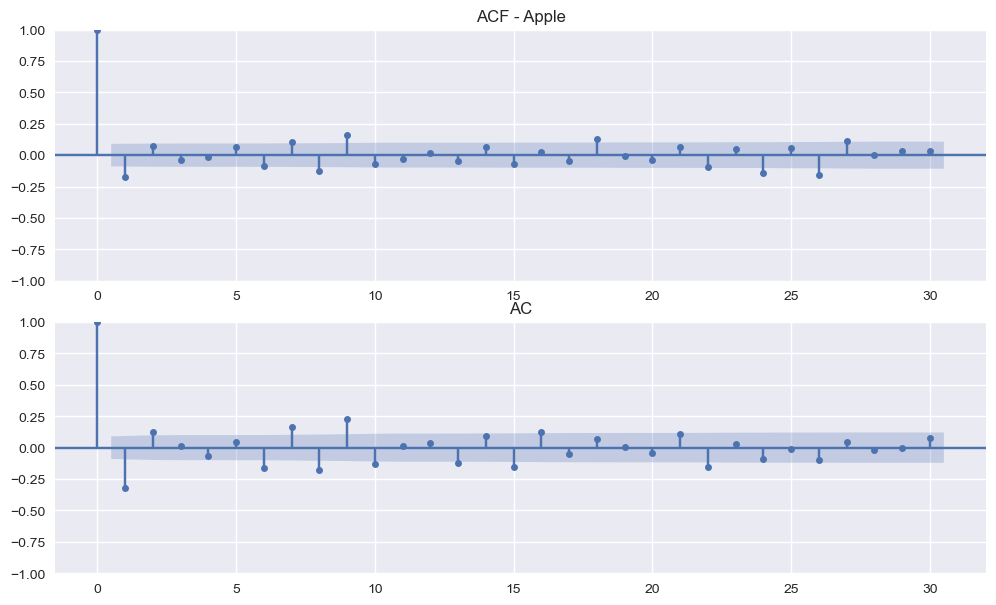

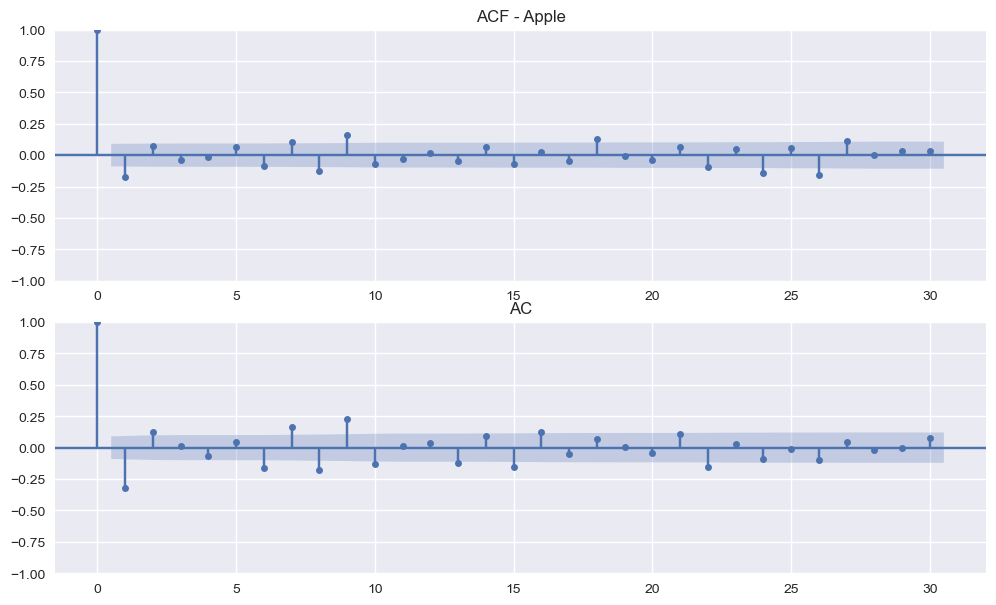

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plt.tight_layout()
sm.graphics.tsa.plot_acf(diff_train_aapl, lags=30,
                       ax=ax[0], title='ACF - Apple')
sm.graphics.tsa.plot_acf(diff_train_msft, lags=30,
                        ax=ax[1], title='AC')

In [29]:
short_moving_average_aapl = diff_train_aapl.rolling(window=9).mean()
long_moving_average_aapl = diff_train_aapl.rolling(window=22).mean()



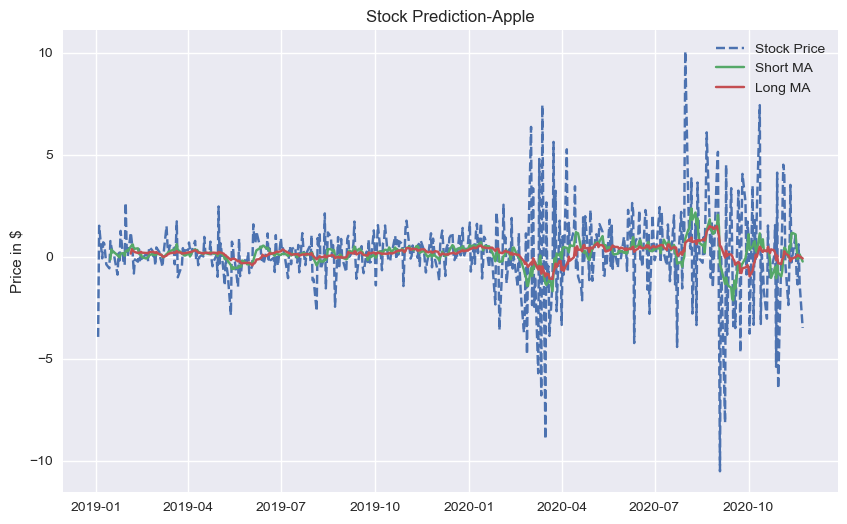

In [30]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(diff_train_aapl.loc[start:end].index,
       diff_train_aapl.loc[start:end],
       label='Stock Price', linestyle='--')
ax.plot(short_moving_average_aapl.loc[start:end].index,
       short_moving_average_aapl.loc[start:end],
       label = 'Short MA', linestyle='solid')
ax.plot(long_moving_average_aapl.loc[start:end].index,
       long_moving_average_aapl.loc[start:end],
       label='Long MA', linestyle='solid')

ax.legend(loc='best')
ax.set_ylabel('Price in $')
ax.set_title('Stock Prediction-Apple')
plt.show()

In [31]:
short_moving_average_msft = diff_train_msft.rolling(window=2).mean()
long_moving_average_msft = diff_train_msft.rolling(window=22).mean()

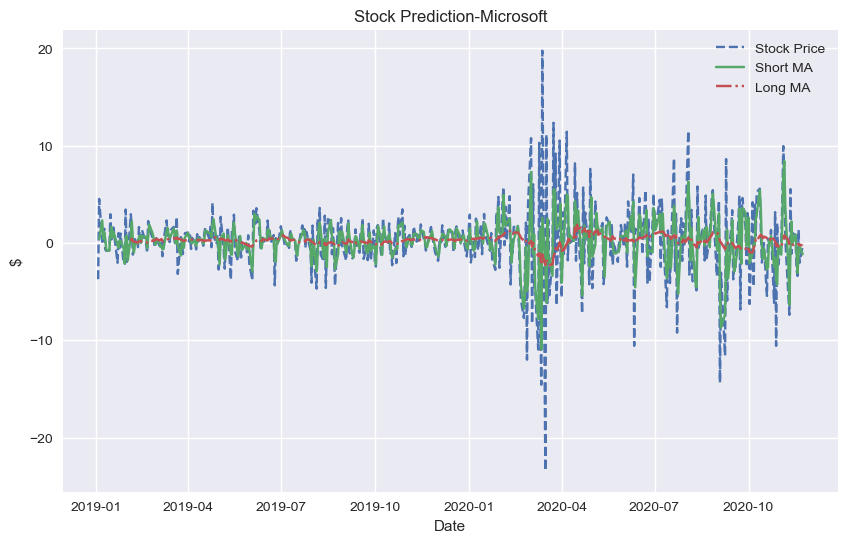

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(diff_train_msft.loc[start:end].index,
       diff_train_msft.loc[start:end],
       label = 'Stock Price', linestyle='--')
ax.plot(short_moving_average_msft.loc[start:end].index,
        short_moving_average_msft.loc[start:end],
        label = 'Short MA', linestyle = 'solid')
ax.plot(long_moving_average_msft.loc[start:end].index,
        long_moving_average_msft.loc[start:end],
        label = 'Long MA', linestyle = '-.')
    
ax.legend(loc='best')
ax.set_ylabel('$')
ax.set_xlabel('Date')
ax.set_title('Stock Prediction-Microsoft')
plt.show()

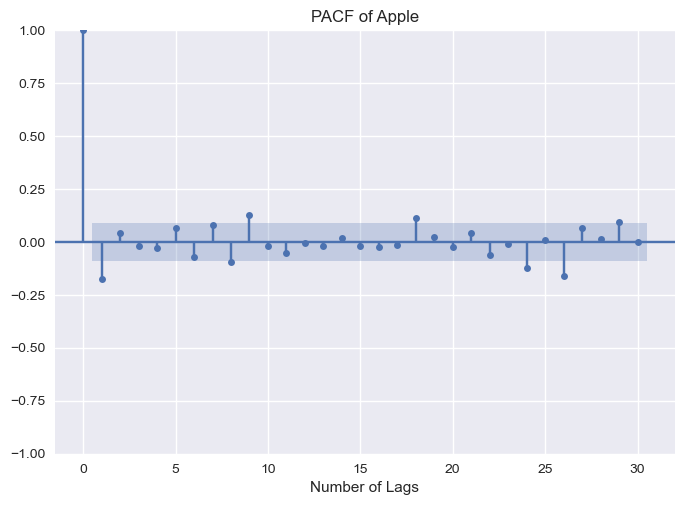

In [33]:
sm.graphics.tsa.plot_pacf(diff_train_aapl, lags=30)
plt.title('PACF of Apple')
plt.xlabel('Number of Lags')
plt.show()

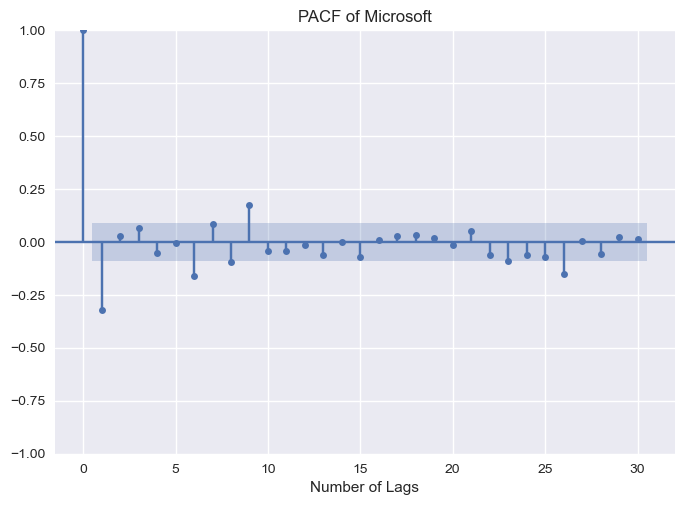

In [34]:
sm.graphics.tsa.plot_pacf(diff_train_msft, lags=30)
plt.title('PACF of Microsoft')
plt.xlabel('Number of Lags')
plt.show()

In [35]:
from statsmodels.tsa.ar_model import AutoReg
import warnings
warnings.filterwarnings('ignore')


In [36]:
ar_aapl = AutoReg(diff_train_aapl.values, lags=29)
ar_fitted_aapl = ar_aapl.fit()

In [37]:
ar_predictions_aapl = ar_fitted_aapl.predict(start=len(diff_train_aapl),
                                            end=len(diff_train_aapl)\
                                            + len(diff_test_aapl) -1,
                                            dynamic=False)

In [38]:
for i in range(len(ar_predictions_aapl)):
    print('==' * 25)
    print('predicted values: {:4f} & actual values:{:.4f}'\
         .format(ar_predictions_aapl[i], diff_test_aapl[i]))

predicted values: 1.653843 & actual values:1.3200
predicted values: -0.834653 & actual values:0.8600
predicted values: -0.999205 & actual values:0.5600
predicted values: 1.137270 & actual values:2.4600
predicted values: -0.110097 & actual values:3.6700
predicted values: 1.787847 & actual values:0.3600
predicted values: -0.917447 & actual values:-0.1400
predicted values: 1.735306 & actual values:-0.6900
predicted values: -1.515902 & actual values:1.5000
predicted values: 1.825864 & actual values:0.6300
predicted values: -1.243826 & actual values:-2.6000
predicted values: -0.536100 & actual values:1.4600
predicted values: -0.106207 & actual values:-0.8300
predicted values: -0.617916 & actual values:-0.6300
predicted values: 1.319116 & actual values:6.1000
predicted values: 0.242518 & actual values:-0.0700
predicted values: 0.451191 & actual values:0.8900
predicted values: -1.307588 & actual values:-2.0400
predicted values: 0.588304 & actual values:1.5700
predicted values: 0.245790 & actu

In [39]:
ar_predictions_aapl = pd.DataFrame(ar_predictions_aapl)
ar_predictions_aapl.index = diff_test_aapl.index

In [40]:
ar_msft = AutoReg(diff_train_msft.values, lags=26)
ar_fitted_msft = ar_msft.fit()

In [41]:
ar_predictions_msft = ar_fitted_msft.predict(start=len(diff_train_msft),
                                            end=len(diff_train_msft)\
                                             +len(diff_test_msft) - 1,
                                             dynamic=False)

In [42]:
ar_predictions_msft = pd.DataFrame(ar_predictions_msft)
ar_predictions_msft.index = diff_test_msft.index

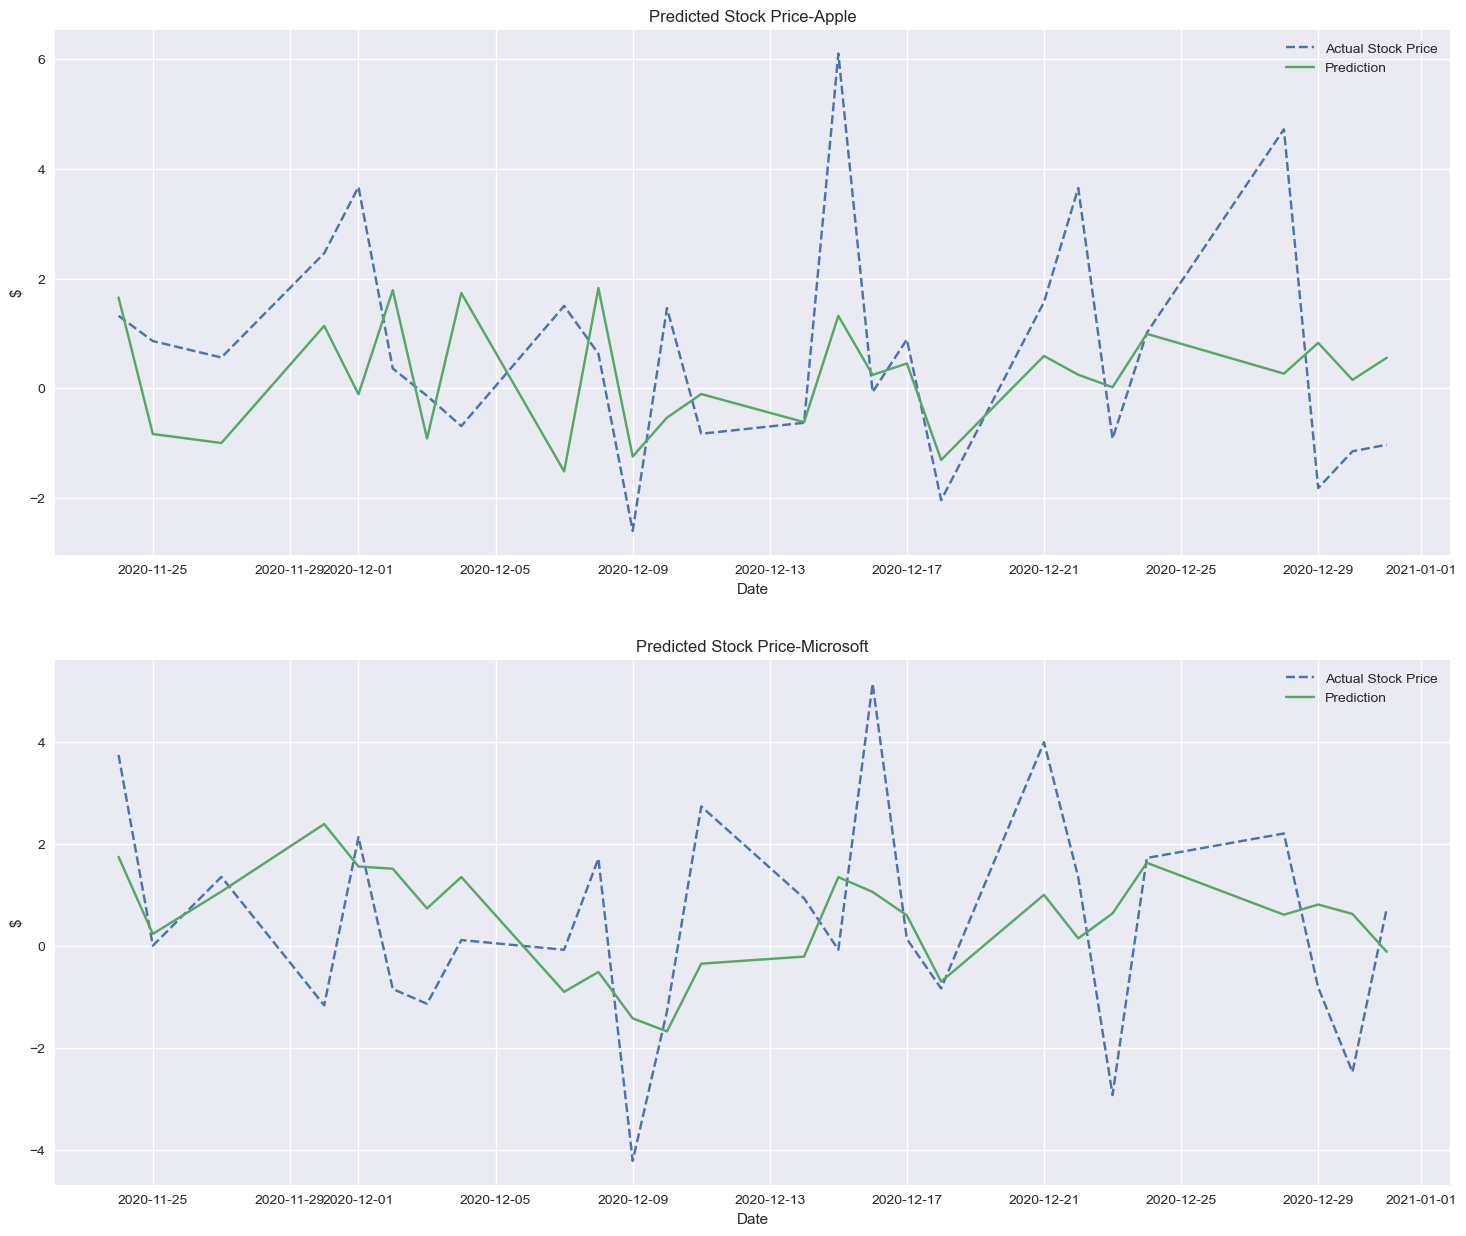

In [43]:
fig, ax = plt.subplots(2,1, figsize=(18, 15))

ax[0].plot(diff_test_aapl, label='Actual Stock Price', linestyle='--')
ax[0].plot(ar_predictions_aapl, linestyle='solid', label="Prediction")
ax[0].set_title('Predicted Stock Price-Apple')
ax[0].legend(loc='best')
ax[1].plot(diff_test_msft, label='Actual Stock Price', linestyle='--')
ax[1].plot(ar_predictions_msft, linestyle='solid', label='Prediction')
ax[1].set_title('Predicted Stock Price-Microsoft')
ax[1].legend(loc='best')

for ax in ax.flat:
    ax.set(xlabel='Date', ylabel='$')
plt.show()

In [80]:
from statsmodels.tsa.arima.model import ARIMA

In [81]:
split = int(len(stock_prices['AAPL'].values) * 0.95)
train_aapl = stock_prices['AAPL'].iloc[:split]
test_aapl = stock_prices['AAPL'].iloc[split:]
train_msft = stock_prices['MSFT'].iloc[:split]
test_msft = stock_prices['MSFT'].iloc[split:]

In [82]:


arima_aapl = ARIMA(train_aapl, order=(9,1,9))
arima_fit_aapl = arima_aapl.fit()


In [83]:
arima_msft = ARIMA(train_msft, order=(6, 1, 6))
arima_fit_msft = arima_msft.fit()

In [84]:
arima_predict_aapl = arima_fit_aapl.predict(start=len(train_aapl),
                                           end=len(train_aapl)\
                                           +len(test_aapl) -1,
                                           dynamic=False)
arima_predict_msft = arima_fit_msft.predict(start=len(train_msft),
                                           end=len(train_msft)\
                                           +len(test_msft) -1,
                                           dynamic=False)

In [85]:
arima_predict_aapl = pd.DataFrame(arima_predict_aapl)
arima_predict_aapl.index = diff_test_aapl.index
arima_predict_msft = pd.DataFrame(arima_predict_msft)
arima_predict_msft.index = diff_test_msft.index

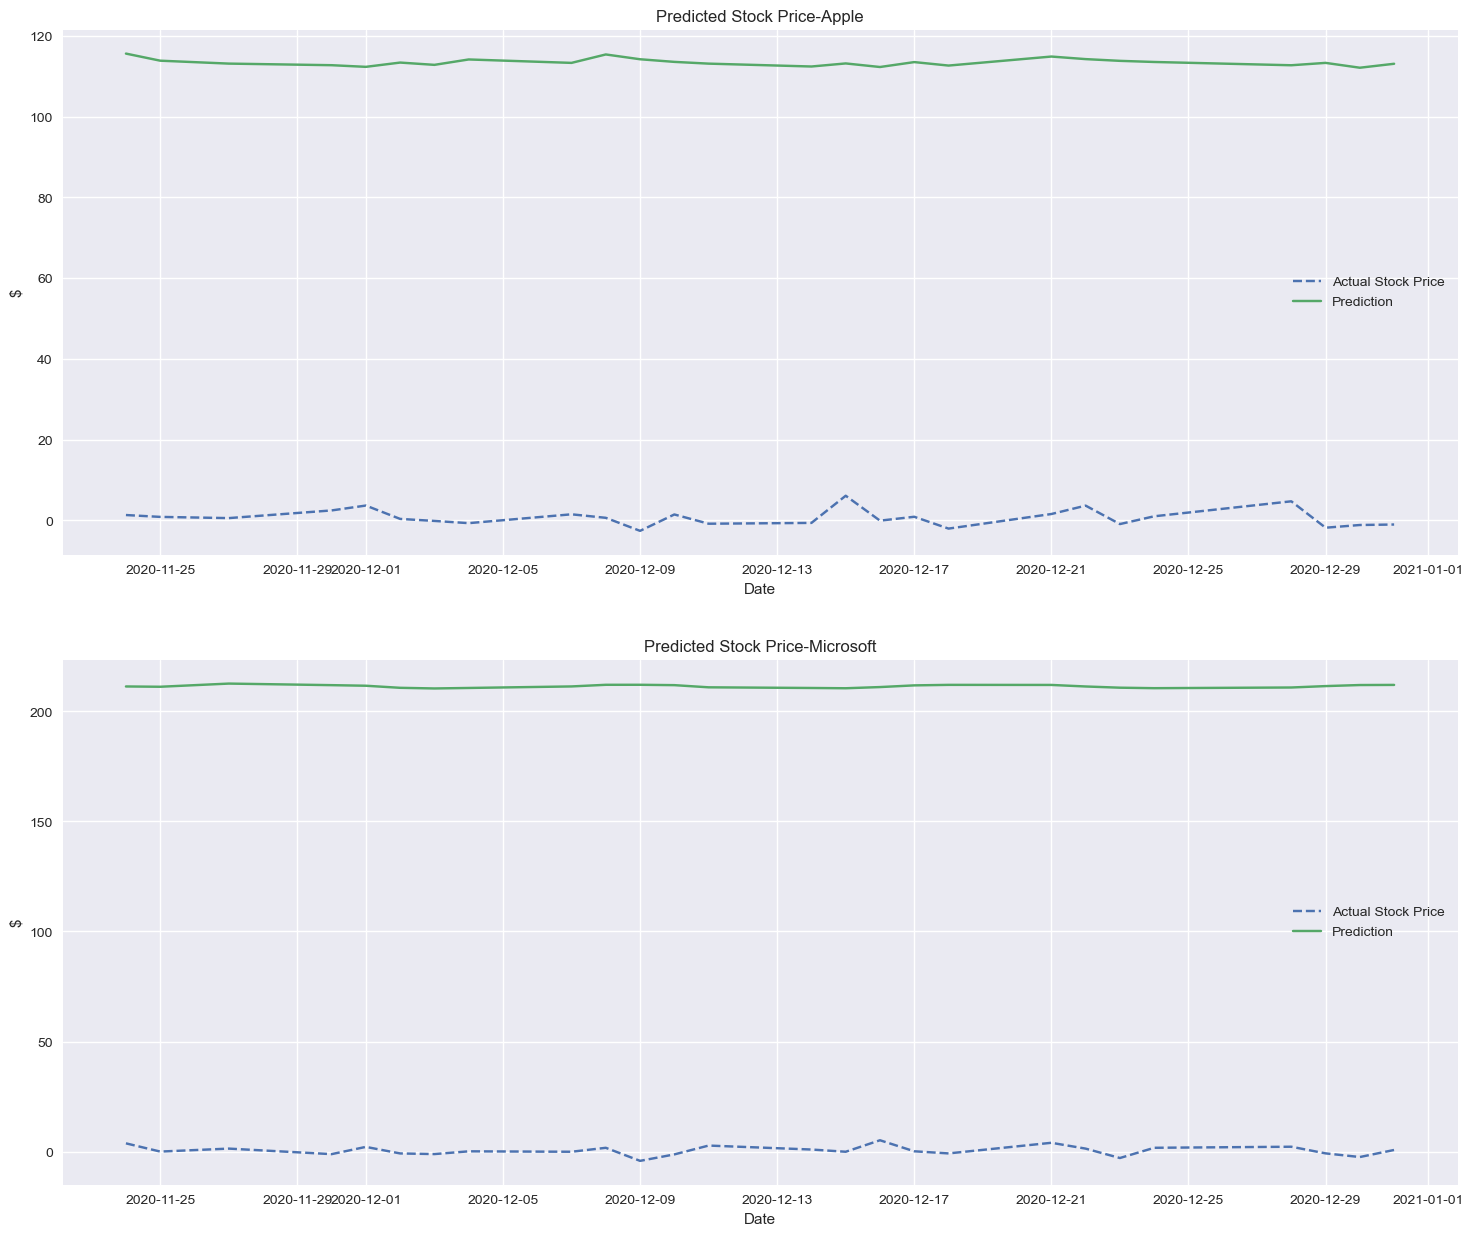

In [86]:
fig, ax =plt.subplots(2, 1, figsize=(18, 15))

ax[0].plot(diff_test_aapl, label='Actual Stock Price', linestyle='--')
ax[0].plot(arima_predict_aapl, linestyle='solid', label='Prediction')
ax[0].set_title('Predicted Stock Price-Apple')
ax[0].legend(loc='best')
ax[1].plot(diff_test_msft, label='Actual Stock Price', linestyle='--')
ax[1].plot(arima_predict_msft, linestyle='solid', label='Prediction')
ax[1].set_title("Predicted Stock Price-Microsoft")
ax[1].legend(loc='best')
for ax in ax.flat:
    ax.set(xlabel='Date', ylabel='$')
plt.show()

In [87]:
import itertools


In [88]:
p = q = range(0, 9)
d = range(0, 3)

pdq = list(itertools.product(p, d, q))
arima_results_aapl = []

for param_set in pdq:
    try:
        arima_aapl = ARIMA(train_aapl, order=param_set)
        arima_fitted_aapl = arima_aapl.fit()
        arima_results_aapl.append(arima_fitted_aapl.aic)
    except:
        continue
    print('**' * 25)
    print('The lowest AIC score is' + \
         '{:.4f} and the corresponding parameters are {}'.format( \
           pd.DataFrame(arima_results_aapl).where(\
           pd.DataFrame(arima_results_aapl).T.notnull().all()).min()[0],
           pdq[arima_results_aapl.index(min(arima_results_aapl))]))

**************************************************
The lowest AIC score is4448.5947 and the corresponding parameters are (0, 0, 0)
**************************************************
The lowest AIC score is3825.1068 and the corresponding parameters are (0, 0, 1)
**************************************************
The lowest AIC score is3396.7849 and the corresponding parameters are (0, 0, 2)
**************************************************
The lowest AIC score is3070.7509 and the corresponding parameters are (0, 0, 3)
**************************************************
The lowest AIC score is2947.0074 and the corresponding parameters are (0, 0, 4)
**************************************************
The lowest AIC score is2947.0074 and the corresponding parameters are (0, 0, 4)
**************************************************
The lowest AIC score is2697.5461 and the corresponding parameters are (0, 0, 6)
**************************************************
The lowest AIC score is2697.5461

**************************************************
The lowest AIC score is1954.9975 and the corresponding parameters are (2, 1, 2)
**************************************************
The lowest AIC score is1953.7162 and the corresponding parameters are (2, 1, 3)
**************************************************
The lowest AIC score is1953.7162 and the corresponding parameters are (2, 1, 3)
**************************************************
The lowest AIC score is1953.7162 and the corresponding parameters are (2, 1, 3)
**************************************************
The lowest AIC score is1953.7162 and the corresponding parameters are (2, 1, 3)
**************************************************
The lowest AIC score is1953.7162 and the corresponding parameters are (2, 1, 3)
**************************************************
The lowest AIC score is1953.7162 and the corresponding parameters are (2, 1, 3)
**************************************************
The lowest AIC score is1953.7162

**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329

**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329 and the corresponding parameters are (4, 1, 4)
**************************************************
The lowest AIC score is1949.8329

In [89]:
arima_appl = ARIMA(train_aapl, order=(4,1,4))
arima_fit_aapl = arima_aapl.fit()


In [90]:
p = q = range(0, 6)
d = range(0, 3)

pdq = list(itertools.product(p, d, q))
arima_results_msft = []

for param_set in pdq:
    try:
        arima_msft = ARIMA(stock_prices['MSFT'], order=param_set)
        arima_fitted_msft = arima_msft.fit()
        arima_results_msft.append(arima_fitted_msft.aic)
    except:
        continue
    print('**' * 25)
    print('The lowest AIC score is {:.4f} and parameters are {}'
         .format(pd.DataFrame(arima_results_msft)
                .where(pd.DataFrame(arima_results_msft).T.notnull()\
                .all()).min()[0],
                pdq[arima_results_msft.index(min(arima_results_msft))]))

**************************************************
The lowest AIC score is 5079.0738 and parameters are (0, 0, 0)
**************************************************
The lowest AIC score is 4447.9685 and parameters are (0, 0, 1)
**************************************************
The lowest AIC score is 4022.8012 and parameters are (0, 0, 2)
**************************************************
The lowest AIC score is 3720.9268 and parameters are (0, 0, 3)
**************************************************
The lowest AIC score is 3720.9268 and parameters are (0, 0, 3)
**************************************************
The lowest AIC score is 3362.4504 and parameters are (0, 0, 5)
**************************************************
The lowest AIC score is 2714.1018 and parameters are (0, 1, 0)
**************************************************
The lowest AIC score is 2672.5919 and parameters are (0, 1, 1)
**************************************************
The lowest AIC score is 2663.8957 and

**************************************************
The lowest AIC score is 2645.6566 and parameters are (3, 1, 2)
**************************************************
The lowest AIC score is 2645.6566 and parameters are (3, 1, 2)
**************************************************
The lowest AIC score is 2645.6566 and parameters are (3, 1, 2)
**************************************************
The lowest AIC score is 2645.6566 and parameters are (3, 1, 2)
**************************************************
The lowest AIC score is 2645.6566 and parameters are (3, 1, 2)
**************************************************
The lowest AIC score is 2645.6566 and parameters are (3, 1, 2)
**************************************************
The lowest AIC score is 2645.6566 and parameters are (3, 1, 2)
**************************************************
The lowest AIC score is 2645.6566 and parameters are (3, 1, 2)
**************************************************
The lowest AIC score is 2645.6566 and

In [91]:
arima_msft = ARIMA(stock_prices['MSFT'], order=(4,1,5))
arima_fit_msft = arima_msft.fit()

In [92]:
arima_predict_aapl = arima_fit_aapl.predict(start=len(train_aapl),
                                           end=len(train_aapl)\
                                           +len(test_aapl) - 1,
                                           dynamic=False)
arima_predict_msft = arima_fit_msft.predict(start=len(train_msft),
                                           end=len(train_msft)\
                                           +len(test_msft) -1,
                                           dynamic=False)

In [93]:
arima_predict_aapl = pd.DataFrame(arima_predict_aapl)
arima_predict_aapl.index = diff_test_aapl.index
arima_predict_msft = pd.DataFrame(arima_predict_msft)
arima_predict_msft.index = diff_test_msft.index 

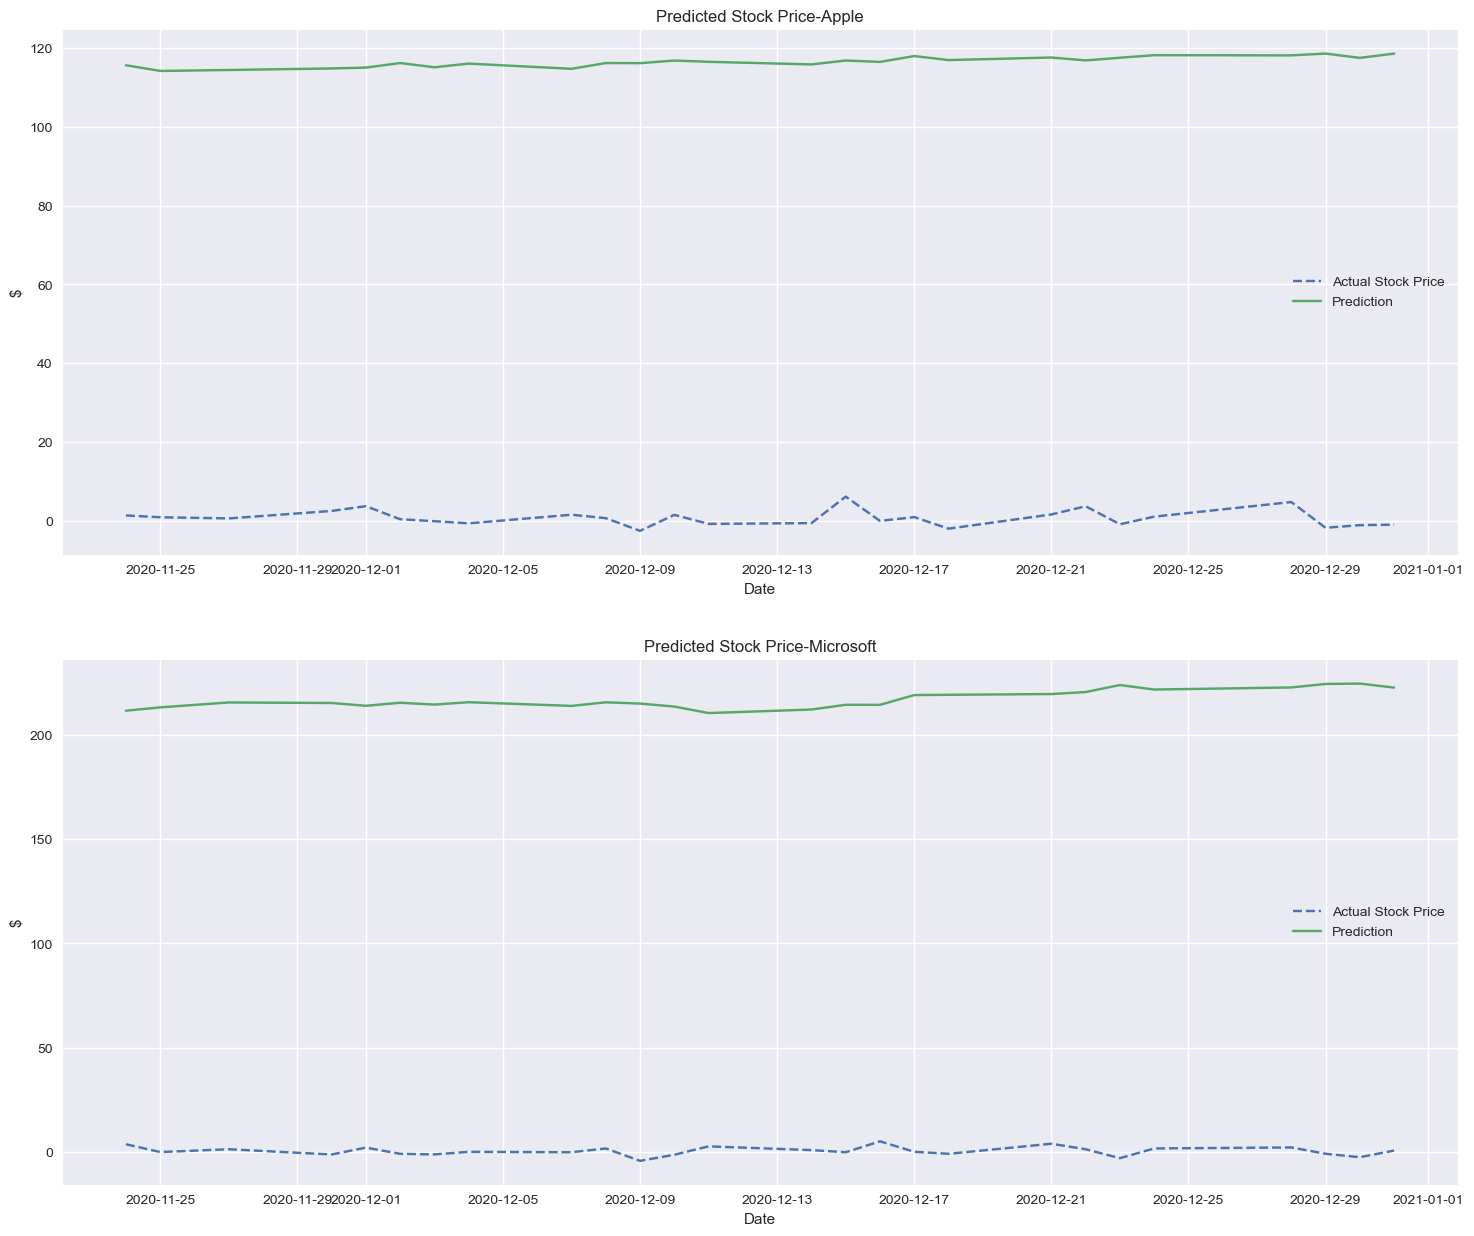

In [94]:
fig, ax = plt.subplots(2, 1, figsize=(18,15))

ax[0].plot(diff_test_aapl, label='Actual Stock Price', linestyle='--')
ax[0].plot(arima_predict_aapl, linestyle='solid', label='Prediction')
ax[0].set_title('Predicted Stock Price-Apple')
ax[0].legend(loc='best')
ax[1].plot(diff_test_msft, label='Actual Stock Price', linestyle='--')
ax[1].plot(arima_predict_msft, linestyle='solid', label='Prediction')
ax[1].set_title('Predicted Stock Price-Microsoft')
ax[1].legend(loc='best')
for ax in ax.flat:
    ax.set(xlabel='Date', ylabel='$')
plt.show()